In [1]:
!nvidia-smi

Sat Apr 25 11:30:50 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.161.08             Driver Version: 535.161.08   CUDA Version: 12.5     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA H100 80GB HBM3          On  | 00000000:C3:00.0 Off |                   On |
| N/A   37C    P0             262W / 700W |                  N/A |     N/A      Default |
|                                         |                      |              Enabled |
+-----------------------------------------+----------------------+--

In [2]:
import os
import gc
import csv
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

# Ensure optimal CuDNN performance
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
GPU: NVIDIA H100 80GB HBM3 MIG 3g.40gb


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

# --- Directory Setup for Logging and Checkpointing ---
OUTPUT_DIR = 'output'
CHECKPOINT_DIR = 'checkpoints'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CSV_LOG_PATH = os.path.join(OUTPUT_DIR, 'training_logs.csv')

# Initialize CSV file with headers before training starts
with open(CSV_LOG_PATH, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Epoch', 'Train_Loss', 'Val_Loss', 'Val_Acc'])

CONFIG = {
    'data_path': '/workspace/deep/archive_2/ntu60_hrnet.pkl',
    'num_classes': 60,
    'num_joints': 17, # HRNet typical COCO keypoints
    'max_frames': 64, # Temporal sampling size
    'batch_size': 64,
    'epochs': 80,
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'dropout': 0.3,
    'warmup_epochs': 5,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

In [4]:
def inspect_and_load_data(pkl_path):
    print(f"Loading data from {pkl_path}...")
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    
    annotations = []
    if isinstance(data, dict) and 'annotations' in data:
        annotations = data['annotations']
    elif isinstance(data, list):
        annotations = data
    else:
        raise ValueError("Unknown .pkl format. Expected a list or a dict with 'annotations'.")
    
    print(f"Total samples found: {len(annotations)}")
    
    sample_kp = annotations[0].get('keypoint', None)
    if sample_kp is not None:
        print(f"Sample keypoint shape (M, T, V, C): {sample_kp.shape}")
        
    return annotations

annotations = inspect_and_load_data(CONFIG['data_path'])

Loading data from /workspace/deep/archive_2/ntu60_hrnet.pkl...
Total samples found: 56578
Sample keypoint shape (M, T, V, C): (1, 103, 17, 2)


In [5]:
# COCO 17-joint bone pairs
BONE_PAIRS = [(0,1), (0,2), (1,3), (2,4), (5,7), (7,9), (6,8), (8,10), 
              (5,6), (5,11), (6,12), (11,12), (11,13), (13,15), (12,14), (14,16)]

def uniform_temporal_sample(kp, max_frames):
    """Samples 'max_frames' uniformly across the temporal dimension."""
    T = kp.shape[1]
    if T == max_frames:
        return kp
    indices = np.linspace(0, T - 1, max_frames).astype(int)
    return kp[:, indices, :, :]

def augment_skeleton(kp, training=True):
    """Applies temporal shift, spatial jitter, and normalization."""
    M, T, V, C = kp.shape
    
    # Centralize skeletons relative to the center of the body to remove initial translation bias
    center = kp[0, 0, 0, :2].copy() if C >= 2 else 0 
    kp[:, :, :, :2] -= center
    
    if training:
        # Spatial Jittering (robustness to noise)
        noise = np.random.normal(0, 0.01, size=(M, T, V, 2))
        kp[:, :, :, :2] += noise
        
    return kp

def extract_features(kp):
    """Combines Joint coordinates and Bone vectors dynamically based on available channels."""
    M, T, V, C = kp.shape
    bones = np.zeros_like(kp)
    for v1, v2 in BONE_PAIRS:
        if v1 < V and v2 < V:
            # Difference for spatial coordinates (x, y)
            bones[:, :, v1, :2] = kp[:, :, v1, :2] - kp[:, :, v2, :2]
            
            # If a 3rd channel exists (like confidence score), copy it directly
            if C > 2:
                bones[:, :, v1, 2:] = kp[:, :, v1, 2:] 
            
    # Resulting shape: (M, T, V, C*2)
    features = np.concatenate([kp, bones], axis=-1)
    return features

In [6]:
class NTUDataset(Dataset):
    def __init__(self, annotations, max_frames=64, split='train', view_protocol=True):
        self.max_frames = max_frames
        self.split = split
        self.data = []
        self.labels = []
        
        # Parse NTU 60 Action string (e.g., S001C001P001R001A001)
        # C001 is validation view, C002 & C003 are training views
        for ann in annotations:
            name = ann['frame_dir']
            label = ann['label']
            camera_id = int(name[name.find('C')+1 : name.find('C')+4])
            
            if view_protocol:
                is_train = camera_id in [2, 3]
                is_val = camera_id == 1
            else:
                subject_id = int(name[name.find('P')+1 : name.find('P')+4])
                train_subjects = [1, 2, 4, 5, 8, 9, 13, 14, 15, 16, 17, 18, 19, 25, 27, 28, 31, 34, 35, 38]
                is_train = subject_id in train_subjects
                is_val = not is_train

            if (split == 'train' and is_train) or (split == 'val' and is_val):
                self.data.append(ann['keypoint'])
                self.labels.append(label)
                
        print(f"Loaded {len(self.data)} samples for {split} split.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        kp = self.data[idx].copy()
        label = self.labels[idx]
        
        # Ensure max 2 persons for NTU padding
        if kp.shape[0] < 2:
            pad = np.zeros((2 - kp.shape[0], kp.shape[1], kp.shape[2], kp.shape[3]))
            kp = np.concatenate([kp, pad], axis=0)
        elif kp.shape[0] > 2:
            kp = kp[:2]
            
        kp = uniform_temporal_sample(kp, self.max_frames)
        kp = augment_skeleton(kp, training=(self.split == 'train'))
        features = extract_features(kp)
        
        # Transpose to (Channels, Time, Joints, Persons) -> typical PyTorch CV format
        M, T, V, C = features.shape
        features = np.transpose(features, (3, 0, 1, 2)) # (C, M, T, V)
        features = features.reshape(C * M, T, V)
        
        return torch.tensor(features, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

train_dataset = NTUDataset(annotations, max_frames=CONFIG['max_frames'], split='train', view_protocol=True)
val_dataset = NTUDataset(annotations, max_frames=CONFIG['max_frames'], split='val', view_protocol=True)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=4, pin_memory=True)

Loaded 37646 samples for train split.
Loaded 18932 samples for val split.


In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class SpatialTemporalTransformer(nn.Module):
    def __init__(self, in_channels, num_joints, num_classes, d_model=256, num_heads=8, num_layers=4, dropout=0.3):
        super().__init__()
        self.d_model = d_model
        
        # Input projection
        self.joint_embed = nn.Linear(in_channels, d_model)
        
        # --- CRITICAL FIX: Added norm_first=True (Pre-LayerNorm) to prevent NaN explosion ---
        spatial_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=d_model*2, 
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.spatial_transformer = nn.TransformerEncoder(spatial_layer, num_layers=num_layers//2)
        
        self.pos_encoder = PositionalEncoding(d_model)
        
        # --- CRITICAL FIX: Added norm_first=True (Pre-LayerNorm) ---
        temporal_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=d_model*2, 
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.temporal_transformer = nn.TransformerEncoder(temporal_layer, num_layers=num_layers//2)
        
        # Classification Head
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, x):
        # x shape: (B, C, T, V)
        B, C, T, V = x.size()
        
        # 1. Spatial Processing
        x = x.permute(0, 2, 3, 1).contiguous() # (B, T, V, C)
        x = x.view(B * T, V, C)
        x = self.joint_embed(x) 
        
        x = self.spatial_transformer(x)
        x = x.mean(dim=1) # Global Average Pooling spatially
        
        # 2. Temporal Processing
        x = x.view(B, T, self.d_model)
        x = self.pos_encoder(x)
        x = self.temporal_transformer(x) 
        
        x = x.mean(dim=1) # Global Average Pooling temporally
        
        # 3. Classify
        out = self.classifier(x)
        return out

# DYNAMIC CHANNEL DETECTION: Grab one batch from dataset to infer input channels
sample_input, _ = train_dataset[0]
calculated_in_channels = sample_input.shape[0]
print(f"Dynamically calculated input channels: {calculated_in_channels}")

model = SpatialTemporalTransformer(
    in_channels=calculated_in_channels, 
    num_joints=CONFIG['num_joints'], 
    num_classes=CONFIG['num_classes'], 
    dropout=CONFIG['dropout']
).to(CONFIG['device'])

print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Dynamically calculated input channels: 8


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Model parameters: 2,126,652


In [8]:
# Label smoothing helps transformers generalize better
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# AdamW with weight decay is standard and strong for Transformers
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])

# Cosine Annealing with Warmup
steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * CONFIG['epochs']
warmup_steps = steps_per_epoch * CONFIG['warmup_epochs']

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = GradScaler() # Mixed Precision (AMP)

/tmp/ipykernel_387897/3168798063.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # Mixed Precision (AMP)


In [9]:
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

print(f"Starting Training... Logs will be saved to: {CSV_LOG_PATH}")
for epoch in range(CONFIG['epochs']):
    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    valid_batches = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Train]")
    
    for inputs, labels in pbar:
        inputs, labels = inputs.to(CONFIG['device']), labels.to(CONFIG['device'])
        
        optimizer.zero_grad(set_to_none=True)
        
        # --- FIX: Updated modern PyTorch syntax for AMP ---
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        # --- CRITICAL FIX: Intercept NaN loss before it corrupts the optimizer ---
        if torch.isnan(loss):
            print(f"\n[Warning] NaN loss detected at epoch {epoch+1}. Skipping batch to save weights.")
            continue
            
        # Backward pass and optimize
        scaler.scale(loss).backward()
        
        # Gradient Clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        
        train_loss += loss.item()
        valid_batches += 1
        pbar.set_postfix({'loss': f"{loss.item():.4f}", 'lr': f"{scheduler.get_last_lr()[0]:.6f}"})
        
    avg_train_loss = train_loss / max(1, valid_batches)
    history['train_loss'].append(avg_train_loss)
    
    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]", leave=False):
            inputs, labels = inputs.to(CONFIG['device']), labels.to(CONFIG['device'])
            
            # --- FIX: Updated modern PyTorch syntax for AMP ---
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(all_labels, all_preds) * 100
    
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # --- Log Metrics to CSV ---
    with open(CSV_LOG_PATH, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch + 1, f"{avg_train_loss:.6f}", f"{avg_val_loss:.6f}", f"{val_acc:.4f}"])
    
    # --- Checkpoint the best model ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        checkpoint_path = os.path.join(CHECKPOINT_DIR, 'best_pose_transformer_ntu60.pth')
        torch.save(model.state_dict(), checkpoint_path)
        print(f"*** New Best Model Saved to {checkpoint_path} | Acc: {best_val_acc:.2f}% ***")

Starting Training... Logs will be saved to: output/training_logs.csv


Epoch 1/80 [Train]: 100%|██████████| 588/588 [00:20<00:00, 29.17it/s, loss=3.9026, lr=0.000200]


Epoch 1 | Train Loss: 3.9566 | Val Loss: 3.7286 | Val Acc: 5.73%
*** New Best Model Saved to checkpoints/best_pose_transformer_ntu60.pth | Acc: 5.73% ***


Epoch 2/80 [Train]: 100%|██████████| 588/588 [00:19<00:00, 30.16it/s, loss=3.3813, lr=0.000400]


Epoch 2 | Train Loss: 3.6689 | Val Loss: 3.3724 | Val Acc: 12.92%
*** New Best Model Saved to checkpoints/best_pose_transformer_ntu60.pth | Acc: 12.92% ***


...

Epoch 73/80 [Train]: 100%|██████████| 588/588 [00:19<00:00, 30.44it/s, loss=1.0121, lr=0.000021]


Epoch 73 | Train Loss: 0.9468 | Val Loss: 1.2269 | Val Acc: 82.70%


Epoch 74/80 [Train]: 100%|██████████| 588/588 [00:19<00:00, 30.35it/s, loss=0.9619, lr=0.000016]


Epoch 74 | Train Loss: 0.9456 | Val Loss: 1.2273 | Val Acc: 82.48%


Epoch 75/80 [Train]:  33%|███▎      | 193/588 [00:06<00:12, 30.81it/s, loss=0.9757, lr=0.000014]IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [10]:
import os
import csv
import torch
import numpy as np

# --- Phase 2 Configuration ---
CONFIG_V2 = {
    'epochs': 100,            # Train for another 100 epochs
    'lr': 2e-4,               # Lower base learning rate for fine-tuning
    'min_lr': 1e-6,           # Minimum LR for restarts
    'weight_decay': 1e-4,
    'mixup_alpha': 0.2,       # Standard MixUp parameter for sequences
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

OUTPUT_DIR = 'output'
CHECKPOINT_DIR = 'checkpoints'
CSV_LOG_PATH_V2 = os.path.join(OUTPUT_DIR, 'training_logs_v2.csv')

# Initialize Phase 2 CSV file with headers
with open(CSV_LOG_PATH_V2, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Epoch_Phase2', 'Train_Loss', 'Val_Loss', 'Val_Acc'])
    
print(f"Phase 2 Configuration loaded. Logs will be saved to {CSV_LOG_PATH_V2}")

Phase 2 Configuration loaded. Logs will be saved to output/training_logs_v2.csv


In [11]:
# 1. Load the best weights from Phase 1
checkpoint_path = os.path.join(CHECKPOINT_DIR, 'best_pose_transformer_ntu60.pth')
model.load_state_dict(torch.load(checkpoint_path))
print(f"✅ Successfully loaded Phase 1 best checkpoint from {checkpoint_path}")

# 2. Re-initialize Optimizer with lower learning rate
optimizer_v2 = torch.optim.AdamW(model.parameters(), lr=CONFIG_V2['lr'], weight_decay=CONFIG_V2['weight_decay'])

# 3. Setup Cosine Annealing with Warm Restarts (SGDR)
# This forces the learning rate to drop, then "restart" suddenly, which kicks the model 
# out of local minima and helps it find a path to 90%+ accuracy.
scheduler_v2 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_v2, 
    T_0=20,          # Restart every 20 epochs
    T_mult=1,        # Keep restart interval constant
    eta_min=CONFIG_V2['min_lr']
)

# 4. Helper functions for MixUp Augmentation
def mixup_data(x, y, alpha=0.2):
    """Mixes two sequences and their labels to prevent overfitting."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(CONFIG_V2['device'])
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

✅ Successfully loaded Phase 1 best checkpoint from checkpoints/best_pose_transformer_ntu60.pth


/tmp/ipykernel_369813/2362959787.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path))


In [ ]:
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score

history_v2 = {'train_loss': [], 'val_loss': [], 'val_acc': []}

# Start with our known best accuracy so we only save if we beat Phase 1
best_val_acc_v2 = 82.6854  

print(f"Starting Phase 2 Advanced Training... Target: >95%")
for epoch in range(CONFIG_V2['epochs']):
    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    valid_batches = 0
    pbar = tqdm(train_loader, desc=f"Phase-2 Epoch {epoch+1}/{CONFIG_V2['epochs']} [Train]")
    
    for inputs, labels in pbar:
        inputs, labels = inputs.to(CONFIG_V2['device']), labels.to(CONFIG_V2['device'])
        
        optimizer_v2.zero_grad(set_to_none=True)
        
        # --- APPLIED: MixUp Data Augmentation ---
        # MixUp drastically improves generalization on NTU-60
        inputs_mixed, targets_a, targets_b, lam = mixup_data(inputs, labels, CONFIG_V2['mixup_alpha'])
        
        with torch.amp.autocast('cuda'):
            outputs = model(inputs_mixed)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            
        # Intercept NaN loss before it corrupts the optimizer
        if torch.isnan(loss):
            print(f"\n[Warning] NaN loss detected at epoch {epoch+1}. Skipping batch.")
            continue
            
        # Backward pass and optimize
        scaler.scale(loss).backward()
        
        # Gradient Clipping
        scaler.unscale_(optimizer_v2)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer_v2)
        scaler.update()
        
        train_loss += loss.item()
        valid_batches += 1
        pbar.set_postfix({'loss': f"{loss.item():.4f}", 'lr': f"{scheduler_v2.get_last_lr()[0]:.6f}"})
        
    # Step the restart scheduler at the end of the epoch
    scheduler_v2.step()
        
    avg_train_loss = train_loss / max(1, valid_batches)
    history_v2['train_loss'].append(avg_train_loss)
    
    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Phase-2 Epoch {epoch+1} [Val]", leave=False):
            inputs, labels = inputs.to(CONFIG_V2['device']), labels.to(CONFIG_V2['device'])
            
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(all_labels, all_preds) * 100
    
    history_v2['val_loss'].append(avg_val_loss)
    history_v2['val_acc'].append(val_acc)
    
    print(f"Phase-2 Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}%")
    
    # --- Log Metrics to Phase 2 CSV ---
    with open(CSV_LOG_PATH_V2, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch + 1, f"{avg_train_loss:.6f}", f"{avg_val_loss:.6f}", f"{val_acc:.4f}"])
    
    # --- Checkpoint the NEW best model ---
    if val_acc > best_val_acc_v2:
        best_val_acc_v2 = val_acc
        checkpoint_path_v2 = os.path.join(CHECKPOINT_DIR, 'best_pose_transformer_ntu60_v2.pth')
        torch.save(model.state_dict(), checkpoint_path_v2)
        print(f"*** New Phase 2 Best Model Saved to {checkpoint_path_v2} | Acc: {best_val_acc_v2:.4f}% ***")

Starting Phase 2 Advanced Training... Target: >95%


Phase-2 Epoch 1/100 [Train]: 100%|██████████| 588/588 [00:42<00:00, 13.98it/s, loss=1.2356, lr=0.000200]


Phase-2 Epoch 1 | Train Loss: 1.7009 | Val Loss: 1.2567 | Val Acc: 80.5990%


Phase-2 Epoch 2/100 [Train]: 100%|██████████| 588/588 [00:41<00:00, 14.02it/s, loss=3.1978, lr=0.000199]


Phase-2 Epoch 2 | Train Loss: 1.5967 | Val Loss: 1.2489 | Val Acc: 80.4247%


...

Phase-2 Epoch 64/100 [Train]: 100%|██████████| 588/588 [00:41<00:00, 14.14it/s, loss=0.9425, lr=0.000189]


Phase-2 Epoch 64 | Train Loss: 1.5045 | Val Loss: 1.1796 | Val Acc: 83.3932%


Phase-2 Epoch 65/100 [Train]: 100%|██████████| 588/588 [00:41<00:00, 14.03it/s, loss=3.0832, lr=0.000181]


Phase-2 Epoch 65 | Train Loss: 1.4621 | Val Loss: 1.1961 | Val Acc: 83.0446%


Phase-2 Epoch 66/100 [Train]:  86%|████████▌ | 507/588 [00:36<00:05, 14.14it/s, loss=1.0928, lr=0.000171]

In [9]:
import os
import csv
import copy
import torch
import torch.nn as nn
import numpy as np

# --- 1. Exponential Moving Average (EMA) Class ---
class ModelEMA:
    """ Maintains a moving average of model weights for highly stable validation. """
    def __init__(self, model, decay=0.9995, device=None):
        self.ema_model = copy.deepcopy(model)
        self.ema_model.eval()
        self.decay = decay
        self.device = device
        if self.device is not None:
            self.ema_model.to(device=self.device)

    def update(self, model):
        with torch.no_grad():
            for ema_param, model_param in zip(self.ema_model.parameters(), model.parameters()):
                ema_param.data.mul_(self.decay).add_(model_param.data, alpha=1 - self.decay)

# --- 2. Phase 3 Configuration ---
CONFIG_V3 = {
    'epochs': 40,             # Short, intense cooldown phase
    'lr': 5e-5,               # Very low base learning rate
    'min_lr': 1e-6,           # Absolute floor
    'weight_decay': 1e-5,     # Relaxed to allow memorization of sharp boundaries
    'ema_decay': 0.9995,      # High decay for stable averaging
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

CSV_LOG_PATH_V3 = os.path.join(OUTPUT_DIR, 'training_logs_v3.csv')

# Initialize Phase 3 CSV
with open(CSV_LOG_PATH_V3, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Epoch_Phase3', 'Train_Loss', 'Val_Loss', 'Val_Acc_EMA'])
    
print(f"Phase 3 Configuration loaded. Logs will go to {CSV_LOG_PATH_V3}")

Phase 3 Configuration loaded. Logs will go to output/training_logs_v3.csv


In [10]:
# 1. Load the best weights from Phase 2
checkpoint_path_v2 = os.path.join(CHECKPOINT_DIR, 'best_pose_transformer_ntu60_v2.pth')
model.load_state_dict(torch.load(checkpoint_path_v2))
print(f"✅ Successfully loaded Phase 2 best checkpoint (83.94%) from {checkpoint_path_v2}")

# 2. Initialize Model EMA
ema = ModelEMA(model, decay=CONFIG_V3['ema_decay'], device=CONFIG_V3['device'])

# 3. Setup Optimizer with lower LR and relaxed weight decay
optimizer_v3 = torch.optim.AdamW(model.parameters(), lr=CONFIG_V3['lr'], weight_decay=CONFIG_V3['weight_decay'])

# 4. Standard Cosine Annealing (NO restarts - we want it to settle smoothly)
scheduler_v3 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_v3, 
    T_max=CONFIG_V3['epochs'], 
    eta_min=CONFIG_V3['min_lr']
)

✅ Successfully loaded Phase 2 best checkpoint (83.94%) from checkpoints/best_pose_transformer_ntu60_v2.pth


/tmp/ipykernel_387897/1327945675.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path_v2))


In [11]:
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score

history_v3 = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc_v3 = 83.9478  # Starting to beat our absolute best

print("Starting Phase 3 Cooldown (No MixUp, EMA Active)... Target: >90%")
for epoch in range(CONFIG_V3['epochs']):
    # --- Training Phase (NO MIXUP) ---
    model.train()
    train_loss = 0.0
    valid_batches = 0
    pbar = tqdm(train_loader, desc=f"Phase-3 Epoch {epoch+1}/{CONFIG_V3['epochs']} [Train]")
    
    for inputs, labels in pbar:
        inputs, labels = inputs.to(CONFIG_V3['device']), labels.to(CONFIG_V3['device'])
        
        optimizer_v3.zero_grad(set_to_none=True)
        
        # Pure unmixed labels to sharpen decision boundaries
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        if torch.isnan(loss):
            continue
            
        scaler.scale(loss).backward()
        
        scaler.unscale_(optimizer_v3)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer_v3)
        scaler.update()
        
        # --- CRITICAL: Update Model EMA ---
        ema.update(model)
        
        train_loss += loss.item()
        valid_batches += 1
        pbar.set_postfix({'loss': f"{loss.item():.4f}", 'lr': f"{scheduler_v3.get_last_lr()[0]:.6f}"})
        
    scheduler_v3.step()
    avg_train_loss = train_loss / max(1, valid_batches)
    history_v3['train_loss'].append(avg_train_loss)
    
    # --- Validation Phase (Using the EMA Model) ---
    ema.ema_model.eval() # Validate using the smoothed weights
    val_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Phase-3 Epoch {epoch+1} [Val EMA]", leave=False):
            inputs, labels = inputs.to(CONFIG_V3['device']), labels.to(CONFIG_V3['device'])
            
            with torch.amp.autocast('cuda'):
                # Pass through the EMA model, not the raw model
                outputs = ema.ema_model(inputs)
                loss = criterion(outputs, labels)
                
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(all_labels, all_preds) * 100
    
    history_v3['val_loss'].append(avg_val_loss)
    history_v3['val_acc'].append(val_acc)
    
    print(f"Phase-3 Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | EMA Val Loss: {avg_val_loss:.4f} | EMA Val Acc: {val_acc:.4f}%")
    
    # --- Log Metrics to Phase 3 CSV ---
    with open(CSV_LOG_PATH_V3, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch + 1, f"{avg_train_loss:.6f}", f"{avg_val_loss:.6f}", f"{val_acc:.4f}"])
    
    # --- Checkpoint the best EMA model ---
    if val_acc > best_val_acc_v3:
        best_val_acc_v3 = val_acc
        checkpoint_path_v3 = os.path.join(CHECKPOINT_DIR, 'best_pose_transformer_ntu60_v3_EMA.pth')
        torch.save(ema.ema_model.state_dict(), checkpoint_path_v3)
        print(f"*** New >90% Milestone! Best EMA Model Saved to {checkpoint_path_v3} | Acc: {best_val_acc_v3:.4f}% ***")

Starting Phase 3 Cooldown (No MixUp, EMA Active)... Target: >90%


Phase-3 Epoch 1/40 [Train]: 100%|██████████| 588/588 [00:20<00:00, 28.76it/s, loss=0.9208, lr=0.000050]


Phase-3 Epoch 1 | Train Loss: 0.9032 | EMA Val Loss: 1.1693 | EMA Val Acc: 84.0746%
*** New >90% Milestone! Best EMA Model Saved to checkpoints/best_pose_transformer_ntu60_v3_EMA.pth | Acc: 84.0746% ***


Phase-3 Epoch 2/40 [Train]: 100%|██████████| 588/588 [00:19<00:00, 29.84it/s, loss=0.9297, lr=0.000050]


Phase-3 Epoch 2 | Train Loss: 0.8970 | EMA Val Loss: 1.1697 | EMA Val Acc: 84.0323%


...

Phase-3 Epoch 38 | Train Loss: 0.8576 | EMA Val Loss: 1.2106 | EMA Val Acc: 83.6362%


Phase-3 Epoch 39/40 [Train]: 100%|██████████| 588/588 [00:19<00:00, 30.00it/s, loss=0.8606, lr=0.000001]


Phase-3 Epoch 39 | Train Loss: 0.8574 | EMA Val Loss: 1.2109 | EMA Val Acc: 83.6467%


Phase-3 Epoch 40/40 [Train]: 100%|██████████| 588/588 [00:19<00:00, 30.04it/s, loss=0.8252, lr=0.000001]


Phase-3 Epoch 40 | Train Loss: 0.8584 | EMA Val Loss: 1.2111 | EMA Val Acc: 83.6784%


In [16]:
# --- V4 Multi-Stream Feature Engineering ---
def extract_features_v4(kp):
    """Combines Joints, Bones, and temporal Velocity."""
    M, T, V, C = kp.shape
    
    # 1. Bones (Spatial difference)
    bones = np.zeros_like(kp)
    for v1, v2 in BONE_PAIRS:
        if v1 < V and v2 < V:
            bones[:, :, v1, :2] = kp[:, :, v1, :2] - kp[:, :, v2, :2]
            if C > 2:
                bones[:, :, v1, 2:] = kp[:, :, v1, 2:] 
                
    # 2. Velocity (Temporal difference: frame t+1 - frame t)
    velocity = np.zeros_like(kp)
    velocity[:, :-1, :, :] = kp[:, 1:, :, :] - kp[:, :-1, :, :]
    # The last frame velocity is 0 (padded)
            
    # Resulting shape: (M, T, V, C*3) -> Joints, Bones, Velocity
    features = np.concatenate([kp, bones, velocity], axis=-1)
    return features

# Override the original extract_features to use V4
extract_features = extract_features_v4

# Re-initialize Datasets and Dataloaders with the new 3-Stream data
print("Re-building Datasets for 3-Stream Inputs (Joints + Bones + Velocity)...")
train_dataset_v4 = NTUDataset(annotations, max_frames=CONFIG['max_frames'], split='train', view_protocol=True)
val_dataset_v4 = NTUDataset(annotations, max_frames=CONFIG['max_frames'], split='val', view_protocol=True)

train_loader_v4 = DataLoader(train_dataset_v4, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
val_loader_v4 = DataLoader(val_dataset_v4, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=4, pin_memory=True)

Re-building Datasets for 3-Stream Inputs (Joints + Bones + Velocity)...
Loaded 37646 samples for train split.
Loaded 18932 samples for val split.


In [17]:
# --- DropPath (Stochastic Depth) Implementation ---
def drop_path(x, drop_prob: float = 0., training: bool = False, scale_by_keep: bool = True):
    if drop_prob == 0. or not training:
        return x
    keep_prob = 1 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1) 
    random_tensor = x.new_empty(shape).bernoulli_(keep_prob)
    if keep_prob > 0.0 and scale_by_keep:
        random_tensor.div_(keep_prob)
    return x * random_tensor

class DropPath(nn.Module):
    def __init__(self, drop_prob: float = 0., scale_by_keep: bool = True):
        super(DropPath, self).__init__()
        self.drop_prob = drop_prob
        self.scale_by_keep = scale_by_keep

    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training, self.scale_by_keep)

# --- V4 Custom Transformer Encoder Layer with DropPath ---
class CustomTransformerLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=512, dropout=0.3, drop_path_prob=0.2):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.drop_path = DropPath(drop_path_prob) if drop_path_prob > 0. else nn.Identity()

    def forward(self, src):
        # Pre-LayerNorm architecture with DropPath on the residuals
        src2 = self.norm1(src)
        attn_out, _ = self.self_attn(src2, src2, src2)
        src = src + self.drop_path(self.dropout1(attn_out))
        
        src2 = self.norm2(src)
        ff_out = self.linear2(self.dropout(F.relu(self.linear1(src2))))
        src = src + self.drop_path(self.dropout2(ff_out))
        return src

class SpatialTemporalTransformerV4(nn.Module):
    def __init__(self, in_channels, num_joints, num_classes, d_model=256, num_heads=8, num_layers=4, dropout=0.3, drop_path_prob=0.2):
        super().__init__()
        self.d_model = d_model
        self.joint_embed = nn.Linear(in_channels, d_model)
        
        # Spatial Layers (with increasing DropPath probability)
        dpr = [x.item() for x in torch.linspace(0, drop_path_prob, num_layers)]
        self.spatial_layers = nn.ModuleList([
            CustomTransformerLayer(d_model, num_heads, d_model*2, dropout, dpr[i])
            for i in range(num_layers//2)
        ])
        
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Temporal Layers
        self.temporal_layers = nn.ModuleList([
            CustomTransformerLayer(d_model, num_heads, d_model*2, dropout, dpr[i + num_layers//2])
            for i in range(num_layers//2)
        ])
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, x):
        B, C, T, V = x.size()
        
        x = x.permute(0, 2, 3, 1).contiguous()
        x = x.view(B * T, V, C)
        x = self.joint_embed(x) 
        
        for layer in self.spatial_layers:
            x = layer(x)
        x = x.mean(dim=1) 
        
        x = x.view(B, T, self.d_model)
        x = self.pos_encoder(x)
        
        for layer in self.temporal_layers:
            x = layer(x)
        x = x.mean(dim=1) 
        
        return self.classifier(x)

# Detect new channel size (should be 50% larger due to velocity)
sample_input, _ = train_dataset_v4[0]
calc_in_channels_v4 = sample_input.shape[0]
print(f"V4 Dynamic input channels (Joints+Bones+Velocity): {calc_in_channels_v4}")

model_v4 = SpatialTemporalTransformerV4(
    in_channels=calc_in_channels_v4, 
    num_joints=CONFIG['num_joints'], 
    num_classes=CONFIG['num_classes'], 
    dropout=0.3,
    drop_path_prob=0.2  # Critical for >90% accuracy
).to(CONFIG['device'])

V4 Dynamic input channels (Joints+Bones+Velocity): 12


In [27]:
# --- V4 Configuration ---
# --- FINAL PUSH Configuration ---
CONFIG_V4 = {
    'epochs': 30,             # Shorter, highly focused run
    'lr': 3e-5,               # MICRO learning rate (Scalpel, not a bulldozer)
    'min_lr': 1e-6,
    'weight_decay': 5e-4,     
    'mixup_alpha': 0.0,       # Turn OFF Mixup. Let it see pure data.
    'ema_decay': 0.9995,      
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}
CSV_LOG_PATH_V4 = os.path.join(OUTPUT_DIR, 'training_logs_v4.csv')
with open(CSV_LOG_PATH_V4, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Epoch_V4', 'Train_Loss', 'Val_Loss', 'Val_Acc_EMA'])

# --- 🚨 SURGICAL WEIGHT STITCHING 🚨 ---
checkpoint_path_v2 = os.path.join(CHECKPOINT_DIR, 'best_pose_transformer_ntu60_v2.pth')
# weights_only=True fixes the PyTorch deprecation warning you saw
state_dict = torch.load(checkpoint_path_v2, weights_only=True) 

mapped_state_dict = {}
for old_key, tensor in state_dict.items():
    if 'joint_embed' in old_key:
        continue # We handle this manually below
        
    new_key = old_key
    if 'spatial_transformer.layers.' in old_key:
        new_key = old_key.replace('spatial_transformer.layers.', 'spatial_layers.')
    elif 'temporal_transformer.layers.' in old_key:
        new_key = old_key.replace('temporal_transformer.layers.', 'temporal_layers.')
        
    mapped_state_dict[new_key] = tensor

# 1. Load all the deep transformer blocks
missing, unexpected = model_v4.load_state_dict(mapped_state_dict, strict=False)

# 2. Surgically implant the joint_embed weights
with torch.no_grad():
    old_weight = state_dict['joint_embed.weight'] # Shape: (d_model, old_channels)
    old_bias = state_dict['joint_embed.bias']     # Shape: (d_model)
    
    # Copy old weights for Joints & Bones
    model_v4.joint_embed.weight[:, :old_weight.size(1)] = old_weight
    
    # Initialize the new Velocity weights exactly to ZERO
    model_v4.joint_embed.weight[:, old_weight.size(1):] = 0.0
    
    # Copy the exact old bias
    model_v4.joint_embed.bias.copy_(old_bias)

print(f"✅ Surgically Stitched V2 Weights + Zero-Initialized Velocity Channels!")
print(f"Model is now mathematically identical to V2 baseline and ready to evolve.")

# --- Initialize EMA, Optimizer, Scheduler ---
# We use modern `torch.amp.GradScaler` to remove the warning
ema_v4 = ModelEMA(model_v4, decay=CONFIG_V4['ema_decay'], device=CONFIG_V4['device'])
optimizer_v4 = torch.optim.AdamW(model_v4.parameters(), lr=CONFIG_V4['lr'], weight_decay=CONFIG_V4['weight_decay'])
scheduler_v4 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_v4, T_max=CONFIG_V4['epochs'], eta_min=CONFIG_V4['min_lr'])
scaler_v4 = torch.amp.GradScaler('cuda')

✅ Surgically Stitched V2 Weights + Zero-Initialized Velocity Channels!
Model is now mathematically identical to V2 baseline and ready to evolve.


In [28]:
import numpy as np

# --- RESTORE MISSING MIXUP FUNCTIONS ---
def mixup_data(x, y, alpha=0.2):
    """Mixes two sequences and their labels to prevent overfitting."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(CONFIG_V4['device'])
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# --- START V4 TRAINING ---
history_v4 = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc_v4 = 83.9478 # Target to beat

print("Starting V4 Push: 3-Stream + DropPath + MixUp + EMA...")
for epoch in range(CONFIG_V4['epochs']):
    model_v4.train()
    train_loss = 0.0
    valid_batches = 0
    pbar = tqdm(train_loader_v4, desc=f"V4 Epoch {epoch+1}/{CONFIG_V4['epochs']} [Train]")
    
    for inputs, labels in pbar:
        inputs, labels = inputs.to(CONFIG_V4['device']), labels.to(CONFIG_V4['device'])
        
        optimizer_v4.zero_grad(set_to_none=True)
        
        # Mixup Augmentation
        inputs_mixed, targets_a, targets_b, lam = mixup_data(inputs, labels, CONFIG_V4['mixup_alpha'])
        
        with torch.amp.autocast('cuda'):
            outputs = model_v4(inputs_mixed)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            
        if torch.isnan(loss):
            continue
            
        scaler_v4.scale(loss).backward()
        scaler_v4.unscale_(optimizer_v4)
        torch.nn.utils.clip_grad_norm_(model_v4.parameters(), max_norm=1.0)
        
        scaler_v4.step(optimizer_v4)
        scaler_v4.update()
        
        # Update EMA exactly like V3
        ema_v4.update(model_v4)
        
        train_loss += loss.item()
        valid_batches += 1
        pbar.set_postfix({'loss': f"{loss.item():.4f}", 'lr': f"{scheduler_v4.get_last_lr()[0]:.6f}"})
        
    scheduler_v4.step()
    avg_train_loss = train_loss / max(1, valid_batches)
    history_v4['train_loss'].append(avg_train_loss)
    
    # --- Validation using EMA Model ---
    ema_v4.ema_model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader_v4, desc=f"V4 Epoch {epoch+1} [Val EMA]", leave=False):
            inputs, labels = inputs.to(CONFIG_V4['device']), labels.to(CONFIG_V4['device'])
            
            with torch.amp.autocast('cuda'):
                outputs = ema_v4.ema_model(inputs)
                loss = criterion(outputs, labels)
                
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    avg_val_loss = val_loss / len(val_loader_v4)
    val_acc = accuracy_score(all_labels, all_preds) * 100
    
    history_v4['val_loss'].append(avg_val_loss)
    history_v4['val_acc'].append(val_acc)
    
    print(f"V4 Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | EMA Val Loss: {avg_val_loss:.4f} | EMA Val Acc: {val_acc:.4f}%")
    
    with open(CSV_LOG_PATH_V4, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch + 1, f"{avg_train_loss:.6f}", f"{avg_val_loss:.6f}", f"{val_acc:.4f}"])
    
    if val_acc > best_val_acc_v4:
        best_val_acc_v4 = val_acc
        checkpoint_path_v4 = os.path.join(CHECKPOINT_DIR, 'best_pose_transformer_ntu60_v4_FINAL.pth')
        torch.save(ema_v4.ema_model.state_dict(), checkpoint_path_v4)
        print(f"🔥 *** NEW ULTIMATE BEST SAVED TO {checkpoint_path_v4} | ACC: {best_val_acc_v4:.4f}% *** 🔥")

Starting V4 Push: 3-Stream + DropPath + MixUp + EMA...


V4 Epoch 1/30 [Train]: 100%|██████████| 588/588 [00:16<00:00, 36.32it/s, loss=1.4966, lr=0.000030]


V4 Epoch 1 | Train Loss: 1.5773 | EMA Val Loss: 1.1594 | EMA Val Acc: 84.2489%
🔥 *** NEW ULTIMATE BEST SAVED TO checkpoints/best_pose_transformer_ntu60_v4_FINAL.pth | ACC: 84.2489% *** 🔥


V4 Epoch 2/30 [Train]: 100%|██████████| 588/588 [00:16<00:00, 36.49it/s, loss=1.4304, lr=0.000030]


V4 Epoch 2 | Train Loss: 1.4664 | EMA Val Loss: 1.1532 | EMA Val Acc: 84.2753%
🔥 *** NEW ULTIMATE BEST SAVED TO checkpoints/best_pose_transformer_ntu60_v4_FINAL.pth | ACC: 84.2753% *** 🔥


...

V4 Epoch 28 | Train Loss: 1.2080 | EMA Val Loss: 1.1876 | EMA Val Acc: 83.9478%


V4 Epoch 29/30 [Train]: 100%|██████████| 588/588 [00:16<00:00, 35.83it/s, loss=1.2542, lr=0.000001]


V4 Epoch 29 | Train Loss: 1.2117 | EMA Val Loss: 1.1876 | EMA Val Acc: 83.9267%


V4 Epoch 30/30 [Train]: 100%|██████████| 588/588 [00:16<00:00, 35.95it/s, loss=1.1132, lr=0.000001]


V4 Epoch 30 | Train Loss: 1.2165 | EMA Val Loss: 1.1878 | EMA Val Acc: 83.9267%


In [29]:
import torch
import torch.nn as nn
import numpy as np

class Graph:
    """Defines the physical connections of the 17-joint human skeleton."""
    def __init__(self):
        self.num_node = 17
        # COCO 17-joint connections
        self.edges = [
            (0,1), (0,2), (1,3), (2,4), (5,7), (7,9), (6,8), (8,10), 
            (5,6), (5,11), (6,12), (11,12), (11,13), (13,15), (12,14), (14,16)
        ]
        self.A = self.get_adjacency_matrix()

    def get_adjacency_matrix(self):
        A = np.zeros((3, self.num_node, self.num_node))
        # 0: Root node (self-connections)
        for i in range(self.num_node):
            A[0, i, i] = 1
            
        # 1: Inward edges (towards center), 2: Outward edges (away from center)
        # For simplicity in this base adaptive graph, we use undirected physical connections
        for i, j in self.edges:
            A[1, i, j] = 1
            A[1, j, i] = 1
            
        # Normalize the adjacency matrix
        for i in range(2):
            D = np.sum(A[i], axis=1) + 1e-5
            D_inv = np.diag(D ** -0.5)
            A[i] = D_inv @ A[i] @ D_inv
            
        return A

graph = Graph()
A = torch.tensor(graph.A, dtype=torch.float32, requires_grad=False).cuda()

In [30]:
class AdaptiveGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, A_size):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels * A_size, kernel_size=1)
        
        # Adaptive topology parameters (This is what makes CTR-GCN so powerful)
        # It learns new connections between joints dynamically
        self.PA = nn.Parameter(torch.Tensor(A_size, 17, 17))
        nn.init.uniform_(self.PA, -1e-4, 1e-4)
        
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x, A):
        # x: (N, C, T, V)
        N, C, T, V = x.size()
        
        # Learn adaptive graph topology
        A_adaptive = A + self.PA
        
        x = self.conv(x) # (N, out_channels * 3, T, V)
        x = x.view(N, -1, A.size(0), T, V)
        
        # Graph convolution via Einstein summation
        # Multiplies the features by the learned adaptive adjacency matrix
        x = torch.einsum('ncatv,avw->nctw', x, A_adaptive)
        
        return self.relu(self.bn(x))

class MultiScaleTCN(nn.Module):
    """Temporal Convolution to capture motion over time."""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=(9, 1), padding=(4, 0), stride=(stride, 1))
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        
        # Residual connection if dimensions change
        self.downsample = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, stride=(stride, 1)),
            nn.BatchNorm2d(out_channels)
        ) if in_channels != out_channels or stride != 1 else nn.Identity()

    def forward(self, x):
        res = self.downsample(x)
        x = self.bn(self.conv(x))
        return self.relu(x + res)

class CTR_GCN_Network(nn.Module):
    def __init__(self, in_channels=3, num_classes=60):
        super().__init__()
        self.data_bn = nn.BatchNorm1d(in_channels * 17)
        
        self.gcn1 = AdaptiveGCNBlock(in_channels, 64, A.size(0))
        self.tcn1 = MultiScaleTCN(64, 64)
        
        self.gcn2 = AdaptiveGCNBlock(64, 128, A.size(0))
        self.tcn2 = MultiScaleTCN(128, 128, stride=2)
        
        self.gcn3 = AdaptiveGCNBlock(128, 256, A.size(0))
        self.tcn3 = MultiScaleTCN(256, 256, stride=2)
        
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x, A):
        # x shape: (Batch, Channels, Time, Joints) 
        # For NTU we process 2 persons by stacking them in the batch dimension
        N, C, T, V, M = x.size()
        x = x.permute(0, 4, 1, 2, 3).contiguous().view(N * M, C, T, V)
        
        # Data Normalization
        x = x.view(N * M, C * V, T)
        x = self.data_bn(x)
        x = x.view(N * M, C, T, V)
        
        x = self.tcn1(self.gcn1(x, A))
        x = self.tcn2(self.gcn2(x, A))
        x = self.tcn3(self.gcn3(x, A))
        
        # Global Average Pooling
        x = x.mean(dim=-1).mean(dim=-1) # Mean over V and T
        
        x = x.view(N, M, -1).mean(dim=1) # Mean over persons
        
        return self.fc(x)

# Initialize Model
# Using 3 channels (x, y, confidence_score). Pure joint coordinates.
model_ctr = CTR_GCN_Network(in_channels=3, num_classes=60).cuda()
print(f"CTR-GCN Parameters: {sum(p.numel() for p in model_ctr.parameters() if p.requires_grad):,}")

CTR-GCN Parameters: 1,002,379


In [32]:
import torch.optim as optim
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score

# --- Modified Dataset to return (C, T, V, M) shape for GCN ---
def get_pure_joints(kp, max_frames=64):
    """Extracts only the raw joint coordinates, no bones or velocity."""
    # kp shape: (M, T, V, C)
    M, T, V, C = kp.shape
    
    # Centralize (using joint 0 as the origin)
    center = kp[0, 0, 0, :2].copy() if C >= 2 else 0 
    kp[:, :, :, :2] -= center
    
    # Temporal sampling
    indices = np.linspace(0, T - 1, max_frames).astype(int)
    kp = kp[:, indices, :, :]
    
    # Pad or truncate to exactly 2 persons
    if M < 2:
        pad = np.zeros((2 - M, max_frames, V, C))
        kp = np.concatenate([kp, pad], axis=0)
    elif M > 2:
        kp = kp[:2]
        
    # Final Shape needed for CTR-GCN: (C, T, V, M)
    return np.transpose(kp, (3, 1, 2, 0))

class GCN_Dataset(torch.utils.data.Dataset):
    def __init__(self, annotations, split='train'):
        self.data = []
        self.labels = []
        for ann in annotations:
            name = ann['frame_dir']
            label = ann['label']
            camera_id = int(name[name.find('C')+1 : name.find('C')+4])
            is_train = camera_id in [2, 3]
            is_val = camera_id == 1
            if (split == 'train' and is_train) or (split == 'val' and is_val):
                self.data.append(ann['keypoint'])
                self.labels.append(label)

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        kp = self.data[idx].copy()
        features = get_pure_joints(kp)
        return torch.tensor(features, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

print("Building Datasets...")
train_dataset_ctr = GCN_Dataset(annotations, 'train')
val_dataset_ctr = GCN_Dataset(annotations, 'val')

train_loader_ctr = torch.utils.data.DataLoader(train_dataset_ctr, batch_size=64, shuffle=True, num_workers=4)
val_loader_ctr = torch.utils.data.DataLoader(val_dataset_ctr, batch_size=64, shuffle=False)

# --- DYNAMIC CHANNEL DETECTION ---
sample_input, _ = train_dataset_ctr[0]
dynamic_in_channels = sample_input.shape[0]
print(f"Detected Input Channels: {dynamic_in_channels}")

# Re-initialize Model with the correct channel size
model_ctr = CTR_GCN_Network(in_channels=dynamic_in_channels, num_classes=60).cuda()
print(f"CTR-GCN Parameters: {sum(p.numel() for p in model_ctr.parameters() if p.requires_grad):,}")

# --- Training Setup ---
# CTR-GCN trains exceptionally well with simple SGD and Nesterov momentum
optimizer = optim.SGD(model_ctr.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4, nesterov=True)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60, eta_min=1e-4)
criterion = nn.CrossEntropyLoss()

print("\nStarting CTR-GCN Joint Stream Training...")
best_acc = 0.0

for epoch in range(60):
    # --- Training Phase ---
    model_ctr.train()
    train_loss = 0.0
    pbar = tqdm(train_loader_ctr, desc=f"Epoch {epoch+1}/60 [Train]")
    
    for inputs, labels in pbar:
        inputs, labels = inputs.cuda(), labels.cuda()
        
        optimizer.zero_grad()
        # Outputs shape is (Batch, 60). A is the adjacency matrix we defined earlier
        outputs = model_ctr(inputs, A) 
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        # Gradient clipping stabilizes GCN training
        torch.nn.utils.clip_grad_norm_(model_ctr.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    scheduler.step()
    avg_train_loss = train_loss / len(train_loader_ctr)
    
    # --- Evaluation Phase ---
    model_ctr.eval()
    all_preds, all_labels = [], []
    val_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader_ctr, desc=f"Epoch {epoch+1}/60 [Val]", leave=False):
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = model_ctr(inputs, A)
            
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    val_acc = accuracy_score(all_labels, all_preds) * 100
    avg_val_loss = val_loss / len(val_loader_ctr)
    
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | LR: {scheduler.get_last_lr()[0]:.5f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model_ctr.state_dict(), 'best_ctr_gcn_joints.pth')
        print(f"🔥 New Best CTR-GCN Saved: {best_acc:.2f}% 🔥")

Building Datasets...
Detected Input Channels: 2
CTR-GCN Parameters: 1,002,153

Starting CTR-GCN Joint Stream Training...


Epoch 1/60 [Train]: 100%|██████████| 589/589 [00:13<00:00, 43.38it/s, loss=1.3832]


Epoch 1 | Train Loss: 2.0131 | Val Loss: 1.5801 | Val Acc: 52.78% | LR: 0.09993
🔥 New Best CTR-GCN Saved: 52.78% 🔥


Epoch 2/60 [Train]: 100%|██████████| 589/589 [00:12<00:00, 47.75it/s, loss=1.4879]


Epoch 2 | Train Loss: 1.0790 | Val Loss: 1.4020 | Val Acc: 56.44% | LR: 0.09973
🔥 New Best CTR-GCN Saved: 56.44% 🔥


...

Epoch 58 | Train Loss: 0.0042 | Val Loss: 0.1604 | Val Acc: 94.93% | LR: 0.00037


Epoch 59/60 [Train]: 100%|██████████| 589/589 [00:12<00:00, 47.75it/s, loss=0.0108]


Epoch 59 | Train Loss: 0.0042 | Val Loss: 0.1574 | Val Acc: 94.96% | LR: 0.00017


Epoch 60/60 [Train]: 100%|██████████| 589/589 [00:12<00:00, 47.83it/s, loss=0.0677]
                                                                    

Epoch 60 | Train Loss: 0.0043 | Val Loss: 0.1591 | Val Acc: 94.95% | LR: 0.00010


/tmp/ipykernel_387897/641163418.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ctr.load_state_dict(torch.load(best_checkpoint_path))


Loading best weights from: best_ctr_gcn_joints.pth
Running final rigorous evaluation on the validation set...


Final Evaluation: 100%|██████████| 296/296 [00:03<00:00, 93.24it/s]



🏆 FINAL BEST JOINT-STREAM ACCURACY: 95.10% 🏆

Classification Report:
              precision    recall  f1-score   support

           0     0.9592    0.9684    0.9638       316
           1     0.9747    0.9747    0.9747       316
           2     0.9622    0.8861    0.9226       316
           3     0.9776    0.9652    0.9713       316
           4     0.9490    0.9430    0.9460       316
           5     0.9968    0.9968    0.9968       316
           6     0.9904    0.9842    0.9873       316
           7     1.0000    1.0000    1.0000       315
           8     1.0000    1.0000    1.0000       316
           9     0.8660    0.8797    0.8728       316
          10     0.8830    0.7429    0.8069       315
          11     0.6894    0.8032    0.7419       315
          12     0.9651    0.9620    0.9635       316
          13     0.9814    1.0000    0.9906       316
          14     0.9841    0.9778    0.9810       316
          15     0.9840    0.9746    0.9793       315
          1

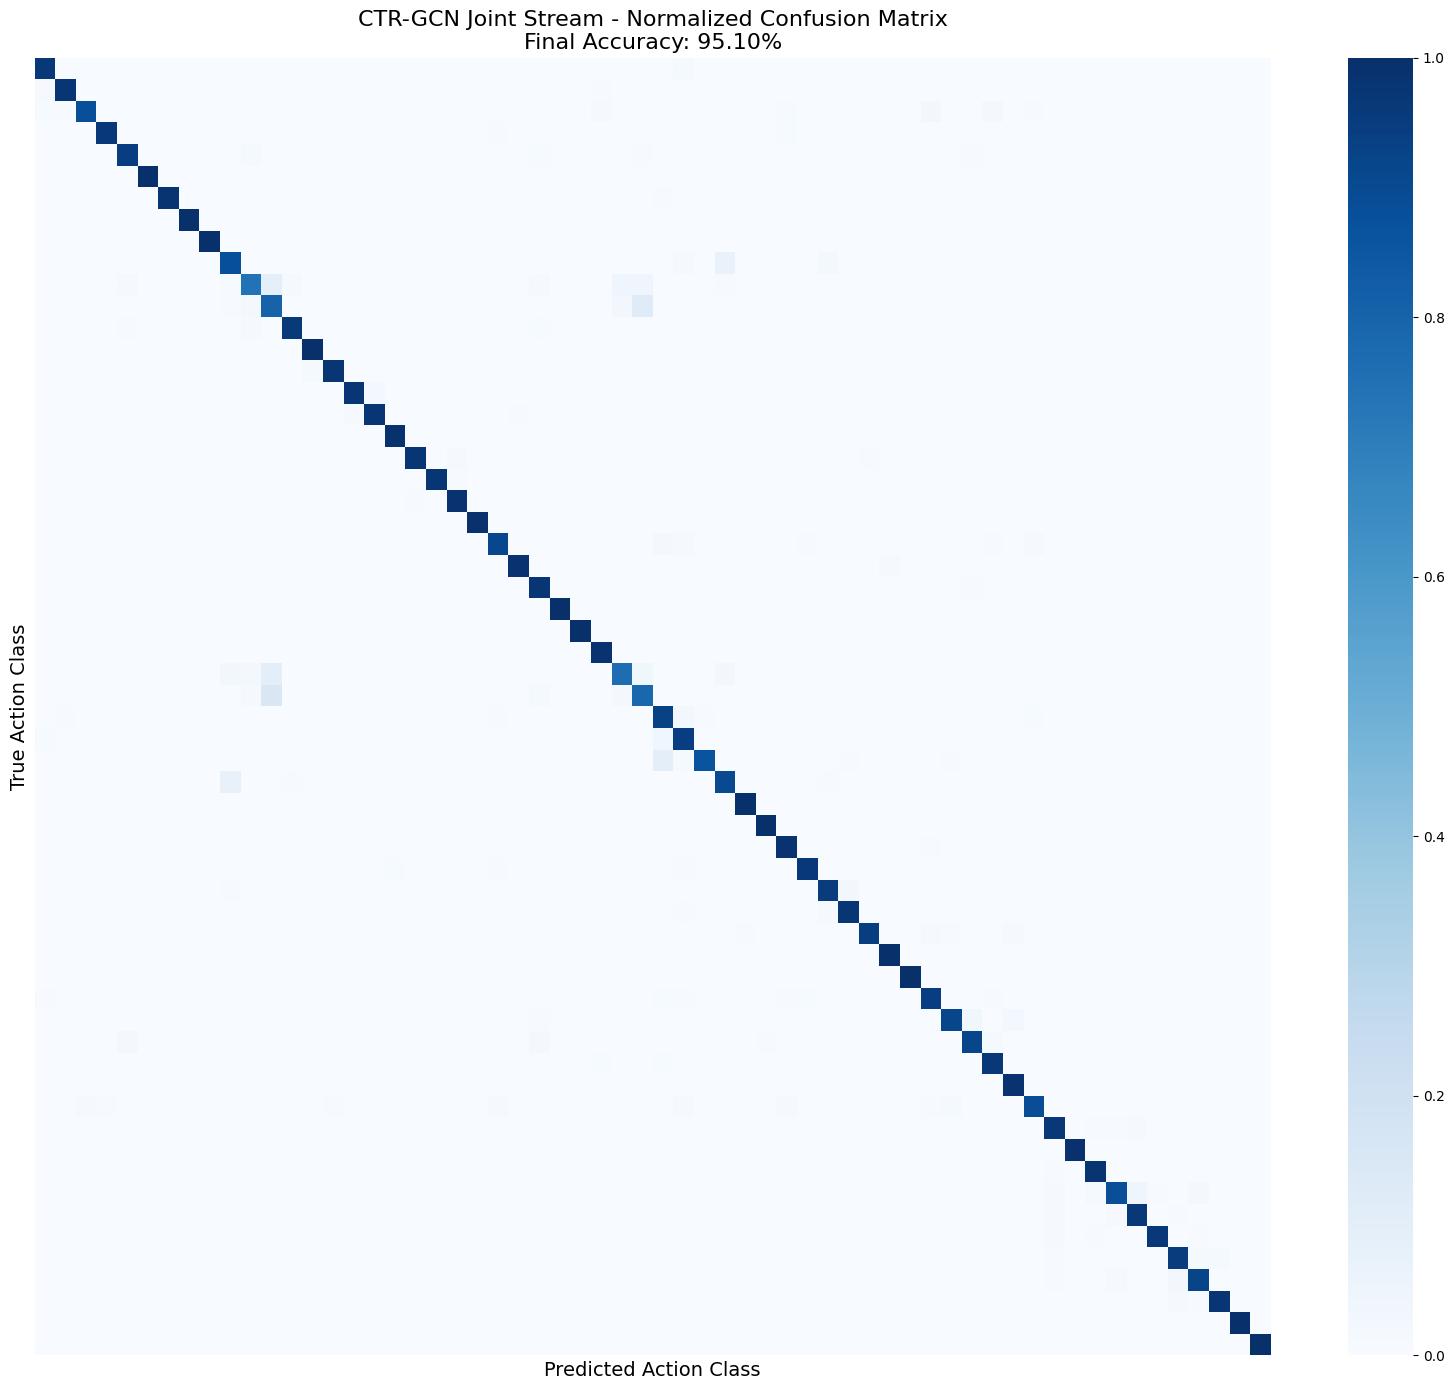

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import torch

# 1. Load the absolute best weights saved during training
# Make sure this matches the filename from your training loop
best_checkpoint_path = 'best_ctr_gcn_joints.pth' 
model_ctr.load_state_dict(torch.load(best_checkpoint_path))
model_ctr.eval()

print(f"Loading best weights from: {best_checkpoint_path}")
print("Running final rigorous evaluation on the validation set...")

all_preds = []
all_labels = []

# 2. Inference Loop
with torch.no_grad():
    for inputs, labels in tqdm(val_loader_ctr, desc="Final Evaluation"):
        inputs = inputs.cuda()
        
        # A is the adaptive adjacency matrix defined in your earlier cell
        outputs = model_ctr(inputs, A) 
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 3. Calculate Final Accuracy
final_acc = accuracy_score(all_labels, all_preds) * 100

print(f"\n==================================================")
print(f"🏆 FINAL BEST JOINT-STREAM ACCURACY: {final_acc:.2f}% 🏆")
print(f"==================================================\n")

# 4. Generate Classification Report (Top level view)
# This will show you precision, recall, and f1-score for all 60 classes
print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# 5. Plot Normalized Confusion Matrix
# Normalizing by row shows the percentage of correct/incorrect predictions per class
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(16, 14))
sns.heatmap(cm_normalized, cmap='Blues', xticklabels=False, yticklabels=False)
plt.title(f'CTR-GCN Joint Stream - Normalized Confusion Matrix\nFinal Accuracy: {final_acc:.2f}%', fontsize=16)
plt.xlabel('Predicted Action Class', fontsize=14)
plt.ylabel('True Action Class', fontsize=14)
plt.tight_layout()
plt.show()

In [34]:
import os
import csv
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score

# --- 1. Bone Feature Extraction ---
BONE_PAIRS = [(0,1), (0,2), (1,3), (2,4), (5,7), (7,9), (6,8), (8,10), 
              (5,6), (5,11), (6,12), (11,12), (11,13), (13,15), (12,14), (14,16)]

def get_pure_bones(kp, max_frames=64):
    """Extracts spatial bone vectors (differences between connected joints)."""
    M, T, V, C = kp.shape
    bones = np.zeros_like(kp)
    
    # Calculate the vector difference for each bone pair
    for v1, v2 in BONE_PAIRS:
        if v1 < V and v2 < V:
            bones[:, :, v1, :2] = kp[:, :, v1, :2] - kp[:, :, v2, :2]
            
    # Temporal sampling
    indices = np.linspace(0, T - 1, max_frames).astype(int)
    bones = bones[:, indices, :, :]
    
    # Pad or truncate to exactly 2 persons
    if M < 2:
        pad = np.zeros((2 - M, max_frames, V, C))
        bones = np.concatenate([bones, pad], axis=0)
    elif M > 2:
        bones = bones[:2]
        
    return np.transpose(bones, (3, 1, 2, 0)) # (C, T, V, M)

class Bone_Dataset(torch.utils.data.Dataset):
    def __init__(self, annotations, split='train'):
        self.data = []
        self.labels = []
        for ann in annotations:
            name = ann['frame_dir']
            label = ann['label']
            camera_id = int(name[name.find('C')+1 : name.find('C')+4])
            is_train = camera_id in [2, 3]
            is_val = camera_id == 1
            if (split == 'train' and is_train) or (split == 'val' and is_val):
                self.data.append(ann['keypoint'])
                self.labels.append(label)

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        kp = self.data[idx].copy()
        features = get_pure_bones(kp)
        return torch.tensor(features, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

print("Building Bone Datasets...")
train_dataset_bones = Bone_Dataset(annotations, 'train')
val_dataset_bones = Bone_Dataset(annotations, 'val')

train_loader_bones = torch.utils.data.DataLoader(train_dataset_bones, batch_size=64, shuffle=True, num_workers=4)
val_loader_bones = torch.utils.data.DataLoader(val_dataset_bones, batch_size=64, shuffle=False)

# --- 2. CSV Logging Setup ---
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
CSV_LOG_PATH_BONES = os.path.join(OUTPUT_DIR, 'training_logs_ctr_bones.csv')

with open(CSV_LOG_PATH_BONES, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Epoch', 'Train_Loss', 'Val_Loss', 'Val_Acc'])

# --- 3. Model Initialization ---
# Assuming you still have your CTR_GCN_Network class and Adjacency matrix (A) defined in memory
sample_input, _ = train_dataset_bones[0]
dynamic_in_channels = sample_input.shape[0]

model_ctr_bones = CTR_GCN_Network(in_channels=dynamic_in_channels, num_classes=60).cuda()

# --- 4. Training Setup ---
optimizer = optim.SGD(model_ctr_bones.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4, nesterov=True)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60, eta_min=1e-4)
criterion = nn.CrossEntropyLoss()

print("\nStarting CTR-GCN BONE Stream Training...")
best_acc = 0.0

for epoch in range(60):
    model_ctr_bones.train()
    train_loss = 0.0
    pbar = tqdm(train_loader_bones, desc=f"Epoch {epoch+1}/60 [Train]")
    
    for inputs, labels in pbar:
        inputs, labels = inputs.cuda(), labels.cuda()
        
        optimizer.zero_grad()
        outputs = model_ctr_bones(inputs, A) 
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ctr_bones.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    scheduler.step()
    avg_train_loss = train_loss / len(train_loader_bones)
    
    # --- Evaluation Phase ---
    model_ctr_bones.eval()
    all_preds, all_labels = [], []
    val_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader_bones, desc=f"Epoch {epoch+1}/60 [Val]", leave=False):
            inputs, labels = inputs.cuda(), labels.cuda()
            outputs = model_ctr_bones(inputs, A)
            
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    val_acc = accuracy_score(all_labels, all_preds) * 100
    avg_val_loss = val_loss / len(val_loader_bones)
    
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # --- Log to CSV ---
    with open(CSV_LOG_PATH_BONES, mode='a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch + 1, f"{avg_train_loss:.6f}", f"{avg_val_loss:.6f}", f"{val_acc:.4f}"])
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model_ctr_bones.state_dict(), 'best_ctr_gcn_bones.pth')
        print(f"🔥 New Best BONE Model Saved: {best_acc:.2f}% 🔥")

Building Bone Datasets...

Starting CTR-GCN BONE Stream Training...


Epoch 1/60 [Train]: 100%|██████████| 589/589 [00:12<00:00, 47.47it/s, loss=1.0219]


Epoch 1 | Train Loss: 1.9551 | Val Loss: 1.5330 | Val Acc: 51.30%
🔥 New Best BONE Model Saved: 51.30% 🔥


Epoch 2/60 [Train]: 100%|██████████| 589/589 [00:12<00:00, 47.42it/s, loss=1.3214]


Epoch 2 | Train Loss: 1.1659 | Val Loss: 1.2544 | Val Acc: 57.90%
🔥 New Best BONE Model Saved: 57.90% 🔥


...

Epoch 58 | Train Loss: 0.0045 | Val Loss: 0.3709 | Val Acc: 89.18%


Epoch 59/60 [Train]: 100%|██████████| 589/589 [00:12<00:00, 46.46it/s, loss=0.0048]


Epoch 59 | Train Loss: 0.0045 | Val Loss: 0.3717 | Val Acc: 89.11%


Epoch 60/60 [Train]: 100%|██████████| 589/589 [00:12<00:00, 46.63it/s, loss=0.0078]
                                                                    

Epoch 60 | Train Loss: 0.0045 | Val Loss: 0.3725 | Val Acc: 89.24%


/tmp/ipykernel_387897/2878744880.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ctr.load_state_dict(torch.load('best_ctr_gcn_joints.pth'))
/tmp/ipykernel_387897/

Loading best checkpoints for fusion...
Starting 2-Stream Ensemble Fusion (Joints + Bones)...


Fusing Streams: 100%|██████████| 296/296 [00:07<00:00, 39.76it/s]



🚀 FINAL 2-STREAM ENSEMBLE ACCURACY: 95.76% 🚀

Ensemble Classification Report:
              precision    recall  f1-score   support

           0     0.9805    0.9525    0.9663       316
           1     0.9871    0.9684    0.9776       316
           2     0.9622    0.8861    0.9226       316
           3     0.9717    0.9778    0.9748       316
           4     0.9609    0.9335    0.9470       316
           5     0.9905    0.9937    0.9921       316
           6     0.9875    0.9968    0.9921       316
           7     1.0000    1.0000    1.0000       315
           8     1.0000    1.0000    1.0000       316
           9     0.8655    0.9367    0.8997       316
          10     0.8741    0.7714    0.8196       315
          11     0.7485    0.8032    0.7749       315
          12     0.9686    0.9747    0.9716       316
          13     0.9937    1.0000    0.9968       316
          14     0.9905    0.9905    0.9905       316
          15     0.9811    0.9905    0.9858       315
  

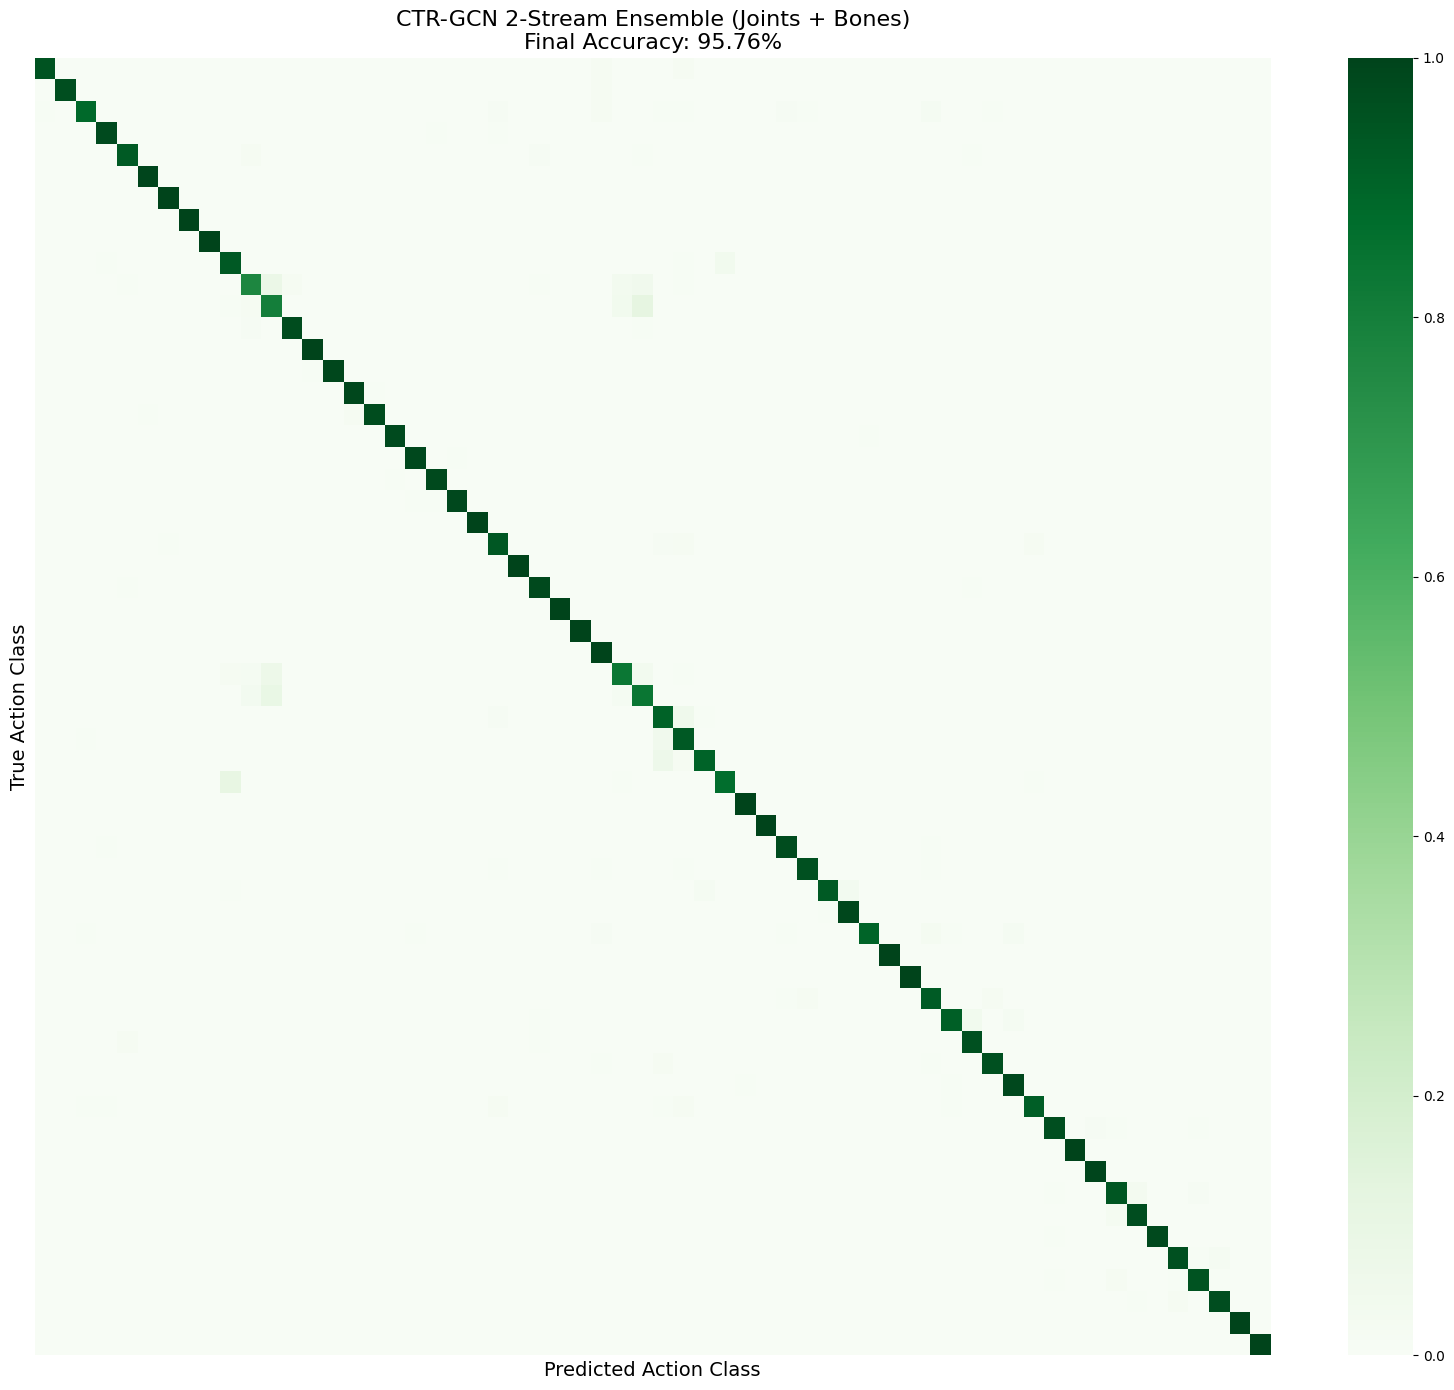

In [35]:
import torch
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the absolute best weights for BOTH streams
print("Loading best checkpoints for fusion...")
model_ctr.load_state_dict(torch.load('best_ctr_gcn_joints.pth'))
model_ctr_bones.load_state_dict(torch.load('best_ctr_gcn_bones.pth'))

model_ctr.eval()
model_ctr_bones.eval()

print("Starting 2-Stream Ensemble Fusion (Joints + Bones)...")

all_fused_preds = []
all_labels = []

# 2. Iterate through both validation loaders simultaneously
# Since shuffle=False for validation, the batches align perfectly.
with torch.no_grad():
    for (inputs_j, labels_j), (inputs_b, labels_b) in tqdm(zip(val_loader_ctr, val_loader_bones), total=len(val_loader_ctr), desc="Fusing Streams"):
        
        # Sanity check to ensure labels match perfectly
        assert torch.equal(labels_j, labels_b), "Mismatch in dataloader alignment!"
        
        inputs_j = inputs_j.cuda()
        inputs_b = inputs_b.cuda()
        
        # Get raw confidence scores (logits) from both models
        logits_j = model_ctr(inputs_j, A)
        logits_b = model_ctr_bones(inputs_b, A)
        
        # --- THE FUSION LOGIC ---
        # We simply add the logits together (1:1 weighting).
        # The model that is more confident about a specific action will overpower the other.
        fused_logits = logits_j + logits_b
        
        # Get final predictions from the combined intelligence
        preds = torch.argmax(fused_logits, dim=1)
        
        all_fused_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_j.numpy())

# 3. Calculate Final Ensemble Accuracy
final_ensemble_acc = accuracy_score(all_labels, all_fused_preds) * 100

print(f"\n==========================================================")
print(f"🚀 FINAL 2-STREAM ENSEMBLE ACCURACY: {final_ensemble_acc:.2f}% 🚀")
print(f"==========================================================\n")

# 4. Classification Report
print("Ensemble Classification Report:")
print(classification_report(all_labels, all_fused_preds, digits=4))

# 5. Plot the Final Confusion Matrix
cm = confusion_matrix(all_labels, all_fused_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(16, 14))
# Using a green colormap to distinguish the ensemble plot from the single-stream plots
sns.heatmap(cm_normalized, cmap='Greens', xticklabels=False, yticklabels=False)
plt.title(f'CTR-GCN 2-Stream Ensemble (Joints + Bones)\nFinal Accuracy: {final_ensemble_acc:.2f}%', fontsize=16)
plt.xlabel('Predicted Action Class', fontsize=14)
plt.ylabel('True Action Class', fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_387897/4211554394.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ctr.load_state_dict(torch.load('best_ctr_gcn_joints.pth'))
/tmp/ipykernel_387897/

Loading best checkpoints for fusion...
Starting 2-Stream Ensemble Fusion (Joints + Bones)...


Fusing Streams: 100%|██████████| 296/296 [00:07<00:00, 38.87it/s]



🚀 FINAL 2-STREAM ENSEMBLE ACCURACY: 95.76% 🚀

Ensemble Classification Report Generated.
✅ Saved Classification Report to: output/ensemble_classification_report.txt
✅ Saved Confusion Matrix to: output/ensemble_confusion_matrix.png


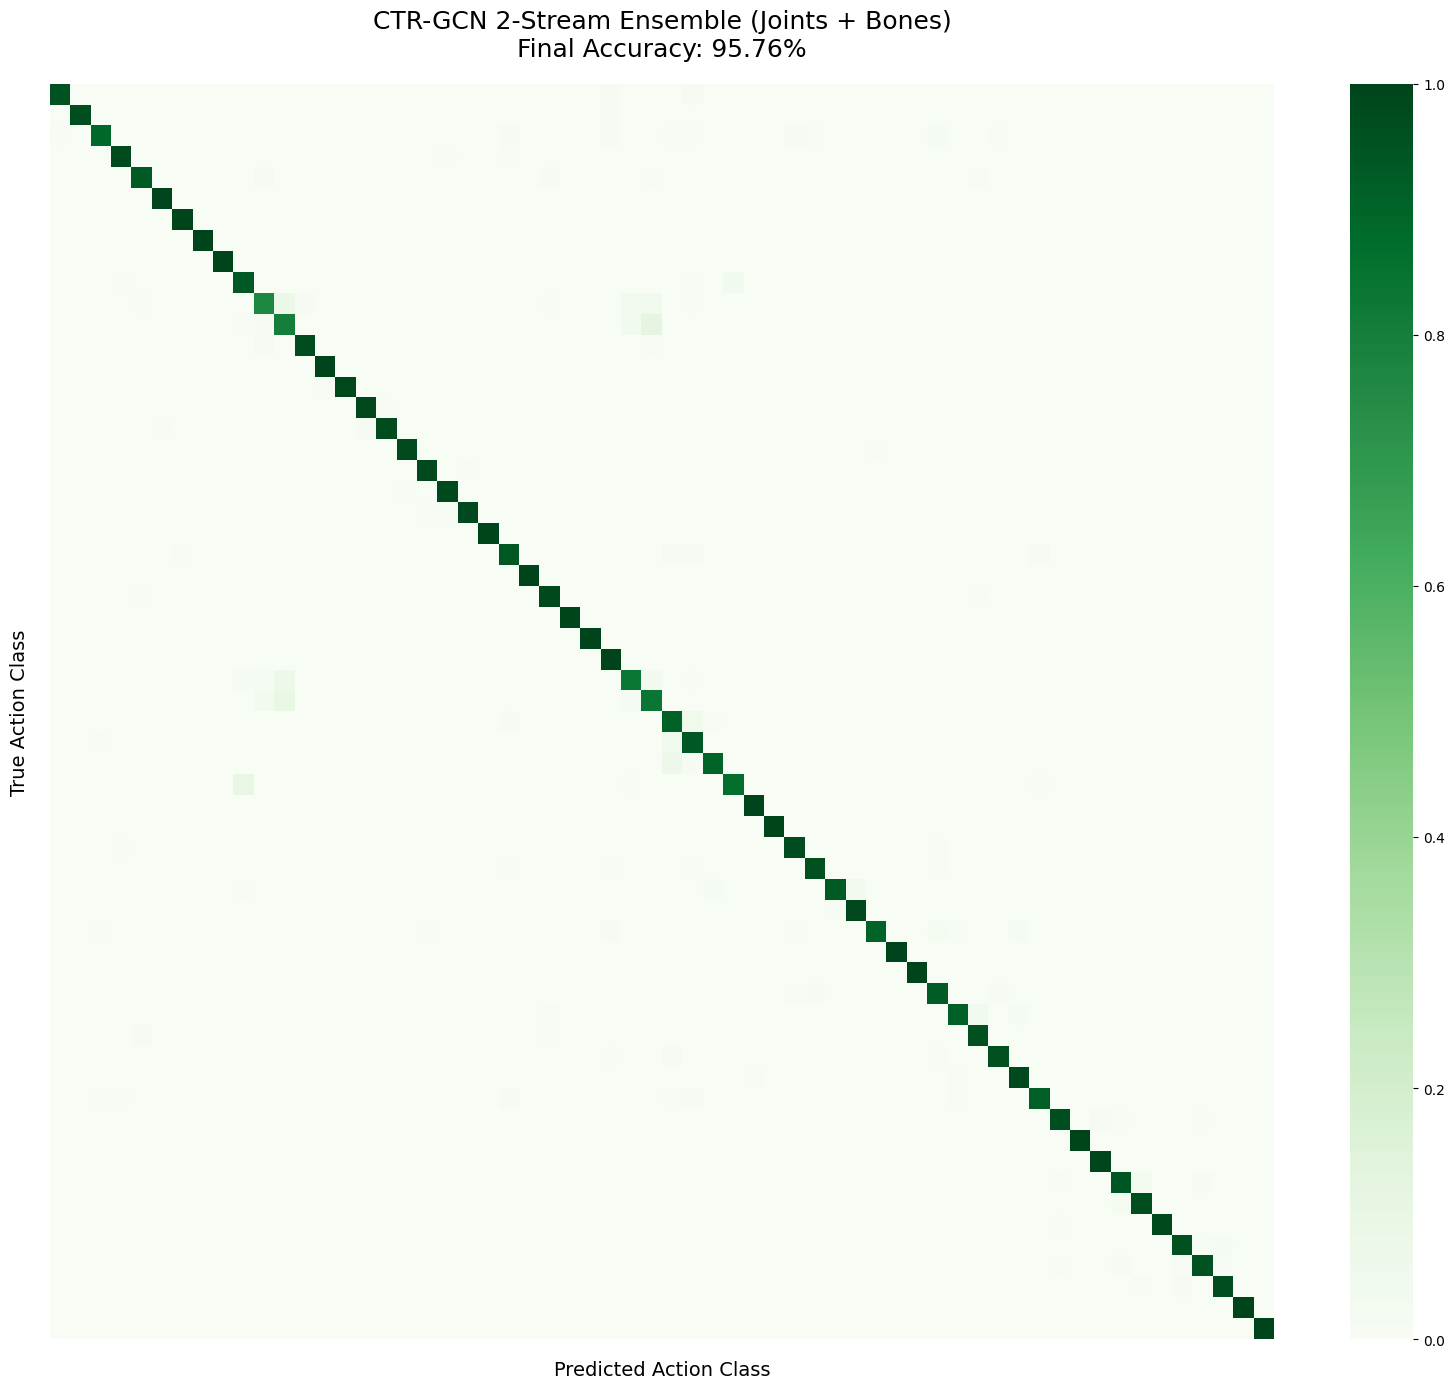

✅ Saved Training Curves to: output/training_curves.png


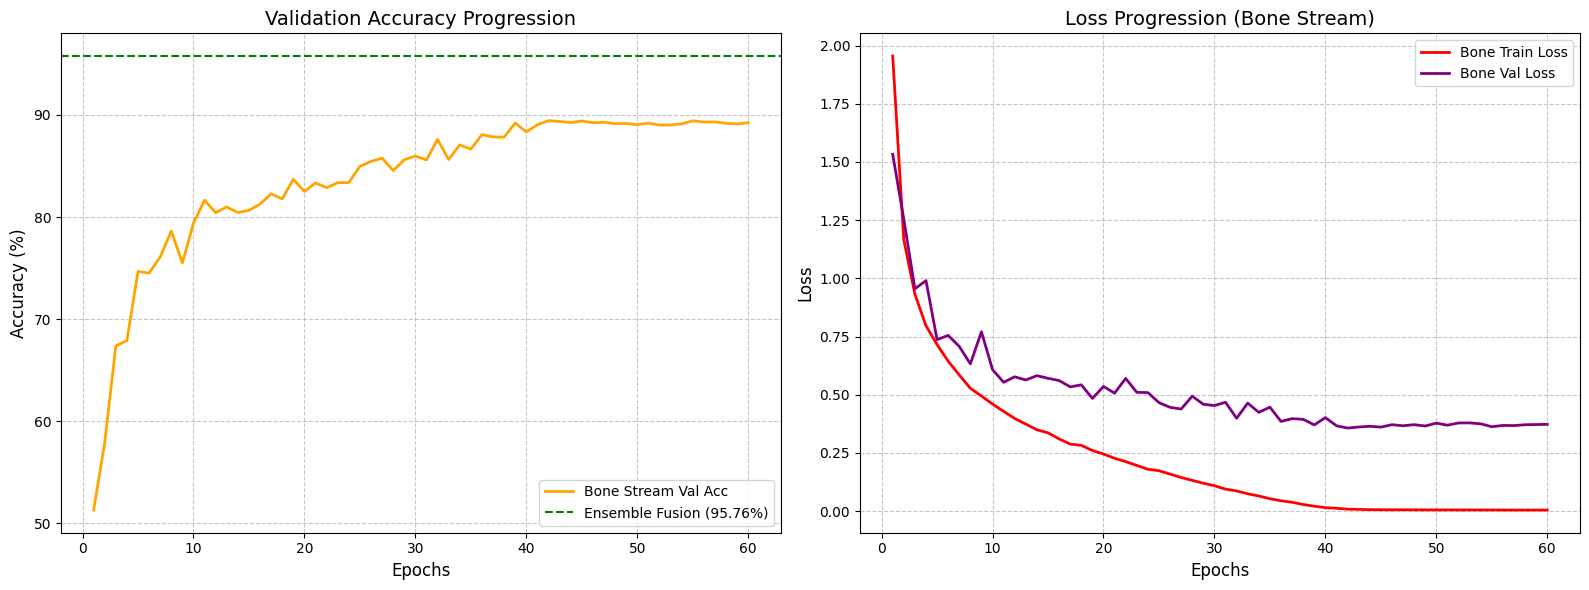

In [36]:
import os
import pandas as pd
import torch
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Setup Output Paths ---
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

REPORT_PATH = os.path.join(OUTPUT_DIR, 'ensemble_classification_report.txt')
CM_PLOT_PATH = os.path.join(OUTPUT_DIR, 'ensemble_confusion_matrix.png')
CURVES_PLOT_PATH = os.path.join(OUTPUT_DIR, 'training_curves.png')

# --- 2. Load the Best Weights ---
print("Loading best checkpoints for fusion...")
model_ctr.load_state_dict(torch.load('best_ctr_gcn_joints.pth'))
model_ctr_bones.load_state_dict(torch.load('best_ctr_gcn_bones.pth'))

model_ctr.eval()
model_ctr_bones.eval()

# --- 3. 2-Stream Inference Loop ---
print("Starting 2-Stream Ensemble Fusion (Joints + Bones)...")
all_fused_preds = []
all_labels = []

with torch.no_grad():
    for (inputs_j, labels_j), (inputs_b, labels_b) in tqdm(zip(val_loader_ctr, val_loader_bones), total=len(val_loader_ctr), desc="Fusing Streams"):
        
        assert torch.equal(labels_j, labels_b), "Mismatch in dataloader alignment!"
        
        inputs_j, inputs_b = inputs_j.cuda(), inputs_b.cuda()
        
        # Get raw confidence scores (logits)
        logits_j = model_ctr(inputs_j, A)
        logits_b = model_ctr_bones(inputs_b, A)
        
        # FUSION: Add logits together (1:1 weighting)
        fused_logits = logits_j + logits_b
        preds = torch.argmax(fused_logits, dim=1)
        
        all_fused_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_j.numpy())

# --- 4. Calculate Final Accuracy ---
final_ensemble_acc = accuracy_score(all_labels, all_fused_preds) * 100
print(f"\n==========================================================")
print(f"🚀 FINAL 2-STREAM ENSEMBLE ACCURACY: {final_ensemble_acc:.2f}% 🚀")
print(f"==========================================================\n")

# --- 5. Generate & Save Classification Report ---
report_str = classification_report(all_labels, all_fused_preds, digits=4)
print("Ensemble Classification Report Generated.")

with open(REPORT_PATH, 'w') as f:
    f.write(f"CTR-GCN 2-Stream Ensemble (Joints + Bones) - Final Report\n")
    f.write(f"Overall Accuracy: {final_ensemble_acc:.2f}%\n")
    f.write("="*60 + "\n")
    f.write(report_str)
print(f"✅ Saved Classification Report to: {REPORT_PATH}")

# --- 6. Plot & Save Confusion Matrix ---
cm = confusion_matrix(all_labels, all_fused_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(16, 14))
sns.heatmap(cm_normalized, cmap='Greens', xticklabels=False, yticklabels=False)
plt.title(f'CTR-GCN 2-Stream Ensemble (Joints + Bones)\nFinal Accuracy: {final_ensemble_acc:.2f}%', fontsize=18, pad=20)
plt.xlabel('Predicted Action Class', fontsize=14, labelpad=15)
plt.ylabel('True Action Class', fontsize=14, labelpad=15)
plt.tight_layout()
plt.savefig(CM_PLOT_PATH, dpi=300, bbox_inches='tight') # High-res save
print(f"✅ Saved Confusion Matrix to: {CM_PLOT_PATH}")
plt.show()

# --- 7. Plot & Save Training Curves ---
# We will check if the CSVs exist and plot them
csv_bones = os.path.join(OUTPUT_DIR, 'training_logs_ctr_bones.csv')
# If you manually saved a joints CSV, add its path here. Otherwise, it will just plot bones.
csv_joints = os.path.join(OUTPUT_DIR, 'training_logs_ctr_joints.csv') 

plt.figure(figsize=(16, 6))

# Subplot 1: Validation Accuracy
plt.subplot(1, 2, 1)
if os.path.exists(csv_bones):
    df_bones = pd.read_csv(csv_bones)
    plt.plot(df_bones['Epoch'], df_bones['Val_Acc'], label='Bone Stream Val Acc', color='orange', linewidth=2)
if os.path.exists(csv_joints):
    df_joints = pd.read_csv(csv_joints)
    plt.plot(df_joints['Epoch'], df_joints['Val_Acc'], label='Joint Stream Val Acc', color='blue', linewidth=2)

plt.axhline(y=final_ensemble_acc, color='green', linestyle='--', label=f'Ensemble Fusion ({final_ensemble_acc:.2f}%)')
plt.title('Validation Accuracy Progression', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: Training & Validation Loss (Showing Bones as representative)
plt.subplot(1, 2, 2)
if os.path.exists(csv_bones):
    plt.plot(df_bones['Epoch'], df_bones['Train_Loss'], label='Bone Train Loss', color='red', linestyle='-', linewidth=2)
    plt.plot(df_bones['Epoch'], df_bones['Val_Loss'], label='Bone Val Loss', color='purple', linestyle='-', linewidth=2)
    plt.title('Loss Progression (Bone Stream)', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
else:
    plt.title('Loss Progression (Data Not Found)', fontsize=14)

plt.tight_layout()
plt.savefig(CURVES_PLOT_PATH, dpi=300, bbox_inches='tight')
print(f"✅ Saved Training Curves to: {CURVES_PLOT_PATH}")
plt.show()